# Домашнее задание 4

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# LU разложение

In [27]:
def lu_decomposition(A):
    n = A.shape[0]
    L = np.zeros_like(A, dtype=float)
    U = np.zeros_like(A, dtype=float)
    
    for i in range(n):
        L[i, i] = 1.0
        for j in range(i, n):
            U[i, j] = A[i, j] - np.sum(L[i, :i] * U[:i, j])
        for j in range(i + 1, n):
            L[j, i] = (A[j, i] - np.sum(L[j, :i] * U[:i, i])) / U[i, i]
    
    return L, U


def forward(L, b):
    n = L.shape[0]
    y = np.zeros_like(b, dtype=float)
    for i in range(n):
        y[i] = b[i] - np.dot(L[i, :i], y[:i])
    return y


def backward(U, y):
    """Решает U x = y для верхнетреугольной матрицы U."""
    n = U.shape[0]
    x = np.zeros_like(y, dtype=float)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - np.dot(U[i, i + 1:], x[i + 1:])) / U[i, i]
    return x


def inverse_matrix(A):
    """Находит обратную матрицу через LU-разложение."""
    n = A.shape[0]
    L, U = lu_decomposition(A)
    inv_A = np.zeros_like(A, dtype=float)
    
    I = np.eye(n)
    for i in range(n):
        e = I[:, i]
        y = forward(L, e)
        x = backward(U, y)
        inv_A[:, i] = x
    return inv_A

A = np.random.rand(5, 5)
A_inv = inverse_matrix(A)

# Проверка
print("A")
print(A)
print("Inverted A")
print(A_inv)
print("Their product (should be Id)")
print(np.round(A @ A_inv, 5))

A
[[0.30138685 0.35014032 0.0917731  0.51985746 0.63832241]
 [0.30194212 0.1639336  0.05727619 0.55797794 0.8650001 ]
 [0.40008376 0.44291349 0.70232339 0.10987167 0.06110048]
 [0.65588046 0.71950766 0.35683522 0.67652204 0.9165857 ]
 [0.23756394 0.14480803 0.80488335 0.12356402 0.93281128]]
Inverted A
[[-12.06675106   6.44653969   1.06379192   4.11820377  -1.8368826 ]
 [  4.85138084  -6.1943793   -2.11932319   1.53204168   1.05770358]
 [  2.90189283   0.06820173   1.87555625  -2.67395589   0.45558477]
 [  6.40747746   1.58848578   2.86070059  -5.01646671  -1.11581558]
 [ -1.03269857  -0.94943494  -1.93919958   1.68510902   1.13034135]]
Their product (should be Id)
[[ 1. -0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.]
 [-0. -0.  1.  0.  0.]
 [-0. -0. -0.  1.  0.]
 [-0.  0. -0.  0.  1.]]


# Задача 1

In [28]:
import numpy as np

def correlated_random(cov_matrix, mean_vector=None):

    n = cov_matrix.shape[0]
    if mean_vector is None:
        mean_vector = np.zeros(n)

    A = np.zeros_like(cov_matrix, dtype=float)
    for i in range(n):
        for j in range(i + 1):
            s = sum(A[i, k] * A[j, k] for k in range(j))
            if i == j:
                A[i, j] = np.sqrt(cov_matrix[i, i] - s)
            else:
                A[i, j] = (cov_matrix[i, j] - s) / A[j, j]

    z = np.random.randn(n)
    x = mean_vector + A @ z
    
    return x


# Задача 2 (на примере лабы 4.2.1)

In [29]:
n = np.arange(15, 0, -1) #черная, белая
#black
d_r_min = np.array([0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3])
d_v_min = np.array([78, 88, 1, 15, 26, 41, 54, 70, 86, 4, 23, 43, 66, 93, 31])

#white
d_r_max = np.array([0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3])
d_v_max = np.array([83, 98, 6, 19, 39, 47, 62, 78, 94, 13, 31, 53, 78, 10, 51])

center_l = 3.75
center_r = 4.26
c = (center_l+center_r)/2

In [30]:
d = 78/8 #10e-5 м
d/=100
d_min = c - (d_r_min + 0.01*d_v_min)
d_max = c - (d_r_max + 0.01*d_v_max)
d_min*=d
d_max*=d
d_min**=2
d_max**=2

In [31]:
kb1, cov1 = np.polyfit(n, d_min, 1, cov=True)
kb2, cov2 = np.polyfit(n, d_max, 1, cov=True)

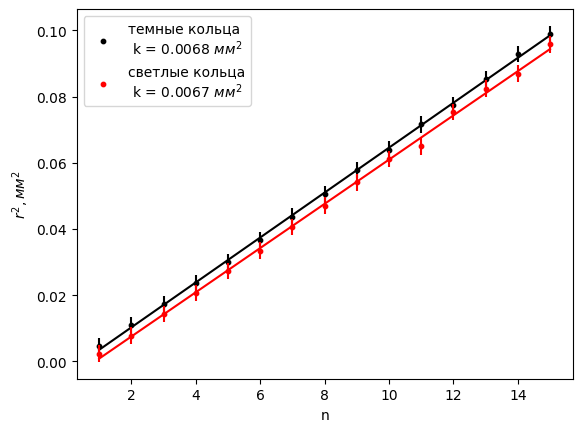

In [32]:
nnew = np.linspace(1, 15, 100)
plt.scatter(n, d_min, color='black', s=10, label=f'темные кольца\n k = {kb1[0]:.2} $мм^2$')
plt.scatter(n, d_max, color='red', s=10, label=f'светлые кольца\n k = {kb2[0]:.2} $мм^2$')

plt.plot(nnew, kb1[0]*nnew+kb1[1], color='black')
plt.plot(nnew, kb2[0]*nnew+kb2[1], color='red')

plt.ylabel('$r^2, мм^2$')
plt.xlabel('n')

plt.errorbar(n, d_min, yerr=2*d/78, fmt='none', color='black')
plt.errorbar(n, d_max, yerr=2*d/78, fmt='none', color='red')

plt.legend()

In [33]:
# создание прямой с шумом

true_w1 = 2.8
true_w0 = 1.5
xs = np.arange(0, 10, 0.5)
noise = np.random.normal(0, 0.45, size=xs.shape)
ys = true_w1 * xs + true_w0 + noise

k, b = np.polyfit(xs, ys, deg=1)

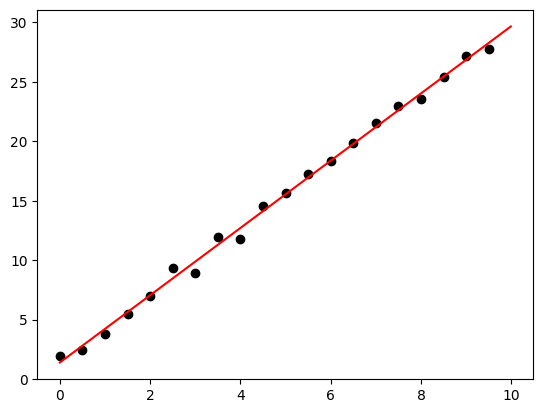

In [34]:
xxs = np.arange(0, 10, 0.01)
plt.scatter(xs, ys, color='black')
plt.plot(xxs, k*xxs + b, color = 'r')